In [1]:
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Cargar modelo ahora en español 
try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo...")
    from spacy.cli import download
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

# TEXTO DE ENTRADA 
with open("La crisis de Oblivion.txt", "r", encoding="utf-8") as f:
    texto_principito = f.read()

# Ahora 'texto_principito' contiene todo el texto del archivo
print(f"Texto cargado con éxito. Longitud: {len(texto_principito)} caracteres.")

# 1. TOKENIZACIÓN
# SpaCy procesa el texto y crea el objeto 'doc' lleno de metadatos
doc = nlp(texto_principito)

# Mostrar los primeros 15 tokens para entender cómo "ve" la máquina el texto
print(f"--- 1. Tokenización (Total tokens: {len(doc)}) ---")
print([token.text for token in doc][:20])


# volvemos a lematizar pero desde doc.sents

corpus_lematizado = []

for oracion in doc.sents:
    lemas_oracion = [
        token.lemma_.lower() 
        for token in oracion 
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    if lemas_oracion:
        corpus_lematizado.append(" ".join(lemas_oracion))

print(f"Total de oraciones procesadas: {len(corpus_lematizado)}")

Texto cargado con éxito. Longitud: 6630 caracteres.
--- 1. Tokenización (Total tokens: 1269) ---
['A', 'punto', 'de', 'entrar', 'en', 'la', 'Cuarta', 'Era', ',', 'en', 'el', 'año', '433', 'de', 'la', 'Tercera', 'Era', ',', 'el', 'emperador']
Total de oraciones procesadas: 56


In [5]:
# implementando las representaciones vectoriales

# Para Bag of Words
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
print(f"--- 2. Bag of Words (Total features: {X_bow.shape[1]}) ---")
print(X_bow.toarray())
print(X_bow.shape)

# Para TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
print(f"--- 3. TF-IDF (Total features: {X_tfidf.shape[1]}) ---")
print(X_tfidf.toarray())
print(X_tfidf.shape)

--- 2. Bag of Words (Total features: 285) ---
[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]]
(56, 285)
--- 3. TF-IDF (Total features: 285) ---
[[0.32092339 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.36586126]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(56, 285)


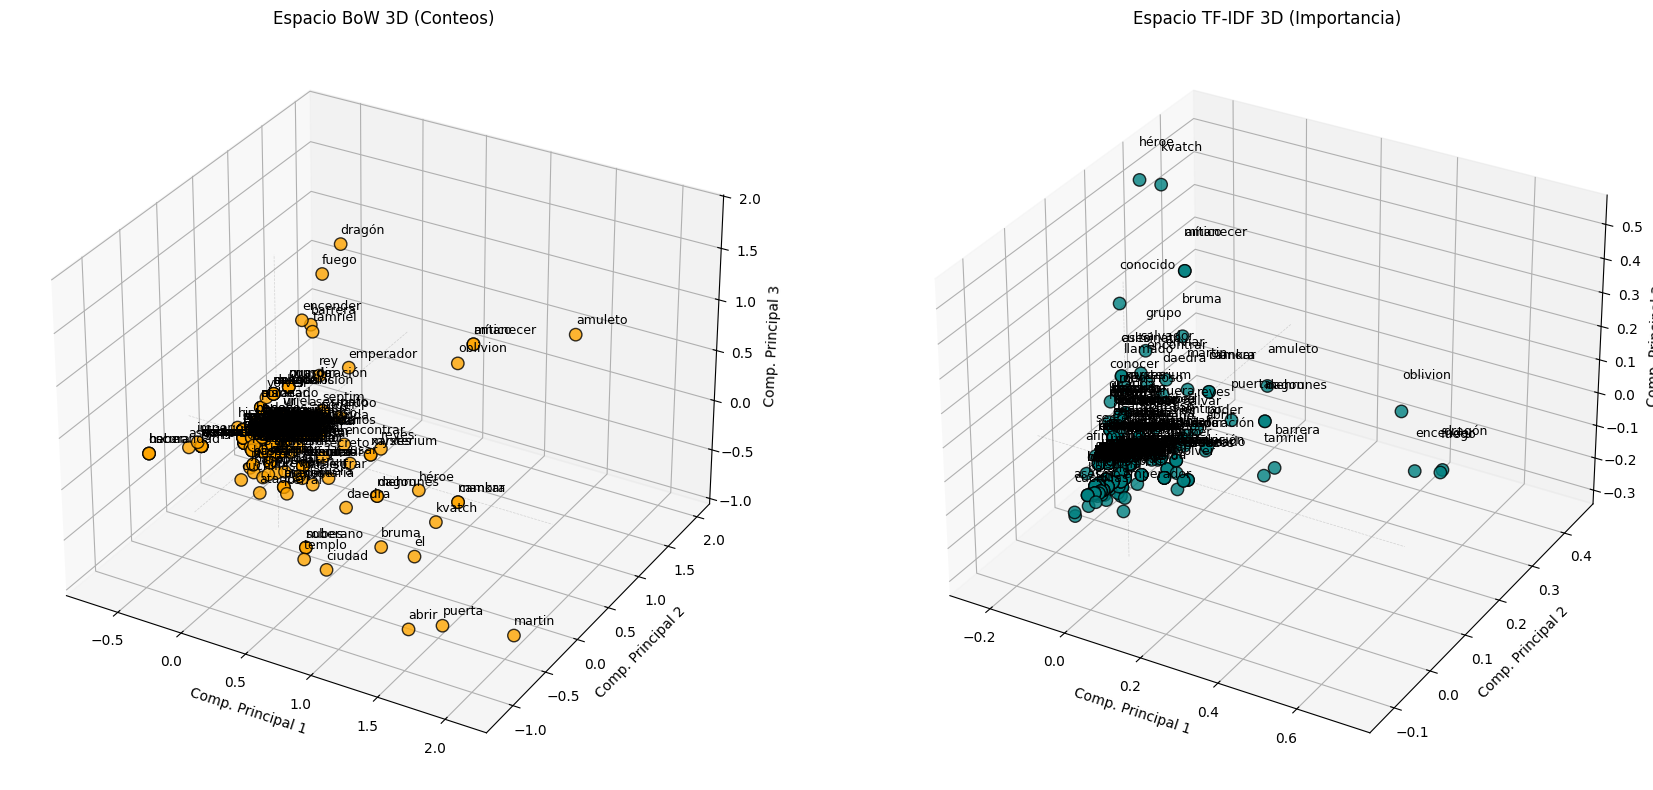

In [6]:
# Graficamos los resultados

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import necesario para 3D
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------
# FUNCIÓN AUXILIAR PARA GRAFICAR EN 3D
# ---------------------------------------------------------
def graficar_palabras_3d(ax, matriz, vocabulario, titulo, color_puntos):
    # 1. TRANSPONER: Filas = Palabras, Columnas = Contextos
    matriz_palabras = matriz.T
    
    # 2. PCA: Reducir a 3 DIMENSIONES
    pca = PCA(n_components=3)
    coords = pca.fit_transform(matriz_palabras.toarray())
    
    # Extraer coordenadas X, Y, Z
    x = coords[:, 0]
    y = coords[:, 1]
    z = coords[:, 2]
    
    # 3. GRAFICAR SCATTER 3D
    # Usamos profundidad visual (depthshade=True) para ayudar a la perspectiva
    ax.scatter(x, y, z, c=color_puntos, s=80, edgecolors='k', alpha=0.8, depthshade=True)
    
    # Etiquetar puntos
    for i, palabra in enumerate(vocabulario):
        # Agregamos un pequeño offset a Z para que el texto flote sobre el punto
        ax.text(x[i], y[i], z[i] + 0.1, palabra, fontsize=9)
        
    ax.set_title(titulo)
    ax.set_xlabel('Comp. Principal 1')
    ax.set_ylabel('Comp. Principal 2')
    ax.set_zlabel('Comp. Principal 3')
    
    # Líneas de referencia en el origen (0,0,0)
    ax.plot([0,0], [0,0], [z.min(), z.max()], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([x.min(), x.max()], [0,0], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([0,0], [y.min(), y.max()], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)


# ---------------------------------------------------------
# CONFIGURACIÓN DE LA FIGURA 3D
# ---------------------------------------------------------
# Creamos una figura ancha para poner dos gráficos lado a lado
fig = plt.figure(figsize=(18, 8))

# --- A. BAG OF WORDS (Izquierda) ---
# subplot(filas, columnas, índice, proyección)
ax1 = fig.add_subplot(121, projection='3d')

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax1, X_bow, vocab_bow, 
                     "Espacio BoW 3D (Conteos)", 
                     "orange")

# --- B. TF-IDF (Derecha) ---
ax2 = fig.add_subplot(122, projection='3d')

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax2, X_tfidf, vocab_tfidf, 
                     "Espacio TF-IDF 3D (Importancia)", 
                     "teal")

plt.tight_layout()
plt.show()